# Week 2: Review of Data Analysis Methods 1

---

Welcome to the second week of classes! Congratulations, you've made it! The goal of this lesson is to introduce and re-introduce the common tools used in first understanding the type of data that you have and it's relationships - i.e., statistics. Understanding your data collection process and the data as a result is one of the first steps on the journey of data visualization and storytelling. Through these next two weeks, we will be walking through how to recognize patterns in your data and whether these patterns are substantial enough to investigate further. As data analysis is the process of applying statistical techniques to describe and evaluate data, statistics will play a main role for us.



---
## Set-up

Let's load the necessary packages for today's class and learn more about the R version we are running.

In [ ]:
library(car)
library(MASS)
library(rstatix)
library(datasets)

sessionInfo()  # R version and package version info

---

## Types of Data

Before we dive into statistics, let's review the different types of data we can have and the categories they can be broken into:

1. Categorical/Qualitative Data: _These variables represent groups of data. Eg.race, sex. Has a fixed number of possible values_
   - Nominal: label variables without providing any quantitative value \(e.g. hair color, nationalities\)
   - Ordinal: has a natural ordering or ranking \(e.g. education level, income level\)

2. Numeric/Quantitative Data: Numerical data is data in the form of numbers. These numbers can be a count of objects, number, or any data which uses numbers.
   - Discrete: Use whole numbers
   - Continuous: can have decimals
     - Interval: intervals between values are equal. Does not have a true 0 e.g. Temperature
     - Ratio: Similar to interval but has a true 0, e.g. Height

Understanding what type of data we have can help us decide which methods are best to display our data. It is important to note that the type of data, while it may feel restrictive, can be switched between. We will briefly touch upon these data types here but we will come back to them in future lessons



In [ ]:
# What type of data can these common R data types represent?
#     integer - Numeric, discrete (also Categorical, ordinal)
#     numeric (double) - Numeric, continuous
#     logical - Categorical, ordinal
#     character - Categorical, nominal
#     factor - Categorical, ordinal

# Use typeof() or class() to check the objects that are part of the list test_objects
test_objects <- list(c(27, 34.5, 1.2, 100), 
                     3L,
                     c(1, 2, 3, 4),
                     c(1L, 2L, 3L, 4L),
                     TRUE,
                     c(TRUE, FALSE, TRUE, FALSE),
                     c("Hello", "there"),
                     "python string",
                     factor(c("early", "middle", "late", "late", "early")))

typeof(c(27, 34.5, 1.2, 100))
class(c(27, 34.5, 1.2, 100))

test_factor <-  factor(c("early", "middle", "late", "late", "early"), levels=c("early", "middle", "late"))
test_factor

lapply(test_objects, typeof)
lapply(test_objects, class)

?lapply 

[1] "double"

[1] "numeric"

[1] early  middle late   late   early 
Levels: early middle late

[[1]]
[1] "double"

[[2]]
[1] "integer"

[[3]]
[1] "double"

[[4]]
[1] "integer"

[[5]]
[1] "logical"

[[6]]
[1] "logical"

[[7]]
[1] "character"

[[8]]
[1] "character"

[[9]]
[1] "integer"

[[1]]
[1] "numeric"

[[2]]
[1] "integer"

[[3]]
[1] "numeric"

[[4]]
[1] "integer"

[[5]]
[1] "logical"

[[6]]
[1] "logical"

[[7]]
[1] "character"

[[8]]
[1] "character"

[[9]]
[1] "factor"

lapply {base},R Documentation
X,a vector (atomic or list) or an expression object. Other objects (including classed objects) will be coerced by base::as.list.
FUN,"the function to be applied to each element of X: see ‘Details’. In the case of functions like +, %*%, the function name must be backquoted or quoted."
...,optional arguments to FUN.
simplify,"logical or character string; should the result be simplified to a vector, matrix or higher dimensional array if possible? For sapply it must be named and not abbreviated. The default value, TRUE, returns a vector or matrix if appropriate, whereas if simplify = ""array"" the result may be an array of “rank” (=length(dim(.))) one higher than the result of FUN(X[[i]])."
USE.NAMES,"logical; if TRUE and if X is character, use X as names for the result unless it had names already. Since this argument follows ... its name cannot be abbreviated."
FUN.VALUE,a (generalized) vector; a template for the return value from FUN. See ‘Details’.
n,integer: the number of replications.
expr,"the expression (a language object, usually a call) to evaluate repeatedly."
x,"a list, typically returned from lapply()."
higher,"logical; if true, simplify2array() will produce a (“higher rank”) array when appropriate, whereas higher = FALSE would return a matrix (or vector) only. These two cases correspond to sapply(*, simplify = ""array"") or simplify = TRUE, respectively."


---

## Types of statistics

There are two main types of statistics that we will be talking about in this lesson today: *Descriptive* and *Inferential*. Descriptive statistics can be thought of as "first pass analysis" were we gather "light" metrics of our data to find patterns. Inferential statistics on the other hand digs deeper to be able to *infer* properties of an underlying distribution and infers properties of a population. First let's play with some descriptive statistics:



---
## Descriptive Statistics
The goal of descriptive statistics is to present data in a summarized and consise way. This can include using indices such as mean, median, range, etc. and can be useful to identify initial patterns and relationships. Lets try and re-familiarize ourselves with some!

---

<div class="alert alert-block alert-info">
    <h2><code>min() and max()</code></h2>
	These functions take numeric values and returns the <code>min</code> or <code>max</code> of the set <br />
    Usage: <code>min(...)</code>, <code>max(...)</code> where ... are values. You can alternatively provide a vector of elements
</div>

In [ ]:
# Try out the next few functions with the numbers 4.9, 26, 2025, 10.2
# If you need more information about a function like min, try running ?min

test_vector <- c(4.9, 26, 2025, 10.2)
min(test_vector)
max(test_vector)

min_value <- min(test_vector)
min_value
print(min_value)

min(4.9, 26, 2025, 10.2)
min(4.9, c(1, 2, 26), 2025, 10.2)

[1] 4.9

[1] 2025

[1] 4.9

[1] 4.9


[1] 4.9

[1] 1

<div class="alert alert-block alert-info">
<h2><code>mean(x,...)</code></h2>
	<code>mean</code> is a function to calculate the average of a vector of numeric values and returns it as a numeric value <br />
    Usage: <code>mean(x, ...)</code>, where x is a vector of numeric elements. 
</div>



In [ ]:
mean(test_vector)

[1] 516.525

<div class="alert alert-block alert-info">
<h2><code>median(x, …)</code></h2>
	<code>median</code> This function takes a list or concatenation of values and finds the middle number. If there are two numbers in the middle, it finds the average of the two middle numbers.
One of the benefits of median over mean is that it is robust to outliers in the data. It can also help to check whether your data is skewed or more normal. We will talk about this later on. <br />
    Usage: <code>median(x, ...)</code>, where x is a vector of numeric elements
</div>

In [ ]:
median(test_vector)

[1] 18.1

Now that we've played with some basic functions, let's import some data to experiment with more detailed descriptive statistics


In [ ]:
# Try out the next few functions with various columns in the iris dataset
head(iris)
tail(iris)
dim(iris)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
145,6.7,3.3,5.7,2.5,virginica
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica
150,5.9,3.0,5.1,1.8,virginica


[1] 150   5

<div class="alert alert-block alert-info">
<h2><code>range(x, na.rm = FALSE)</code></h2>
	<code>range</code> This function will return the minimum and maximum values of the argument given.  <br />
</div>

In [ ]:
range(iris$Sepal.Length)
range(iris$Sepal.Width)
range(iris[, "Sepal.Width"]) # alternative ways of calling the sepal width column
range(iris[["Sepal.Width"]])

apply(iris, 2, range)

[1] 4.3 7.9

[1] 2.0 4.4

[1] 2.0 4.4

[1] 2.0 4.4

Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
4.3,2.0,1.0,0.1,setosa
7.9,4.4,6.9,2.5,virginica


<div class="alert alert-block alert-info">
<h2><code>quantile(x, probs = seq(0, 1, 0.25), na.rm = FALSE, ...)</code></h2>
	<code>quantile</code> This function will return the quantiles at the given probabilities. <br />
</div>

In [ ]:
quantile(iris$Sepal.Length)
quantile(iris$Sepal.Length, c(0.01, 0.99))  # Can be helpful for removing outliers

0%  25%  50%  75% 100% 
 4.3  5.1  5.8  6.4  7.9

1% 99% 
4.4 7.7

<div class="alert alert-block alert-info">
<h2><code>summary(object, …)</code></h2>
    Summary is a generic function used to produce result summaries of the results of various model fitting functions. Default values include minimum, first quartile, median, mean, third quartile and max for numeric data or number of occurances for factorial or character data. It can be very useful to gather a lot of information about your data in one function 

</div>

In [ ]:
summary(iris)

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                

<div class="alert alert-block alert-info">
<h2><code>sd(x, na.rm = FALSE)</code></h2>
    This function computes the standard deviation of the values in x. If na.rm is TRUE then missing values are removed before computation proceeds. This function can be very useful to see the spread of your data around the mean. 

</div>

In [ ]:
sd(iris$Sepal.Length)

[1] 0.8280661

<div class="alert alert-block alert-info">
<h2><code>var(x, y = NULL, na.rm = FALSE, ...)</code></h2>
    This function computes the variance of the values in x. If na.rm is TRUE then missing values are removed before computation proceeds. This function can be very useful to see the spread of your data around the mean.
</div>

In [ ]:
var(iris$Sepal.Length)

[1] 0.6856935

---

## Inferential Statistics

Uses statistical tests to draw conclusions about the data.

Statistical tests are phrased in the form of a **hypothesis**, which determine whether a certain belief can be deemed as true (plausible) or not, based on the data (i.e., the sample(s)).

A null hypothesis will state that there is no significant difference between groups, or there is no significant effect of an explanatory variable on a response variable. The alternative hypothesis will state that there is a significant difference or effect; a prediction typically has directionality (e.g., an explanatory variable has a positive or negative effect on the response variable).

Then, a p-value will test the probability that the null hypothesis will occur. The definition of a p-value is: the probability of observing this data under the assumption that the null hypothesis is true. In other words, it is the probability of an observed difference between groups due to chance. If the p-value is extremely small, then the chance of observing your data due to chance is highly unlikely, so you can conclude that there is a process that is effecting your observed data.

A statistical test aims to **reject the null hypothesis**. If your statistical test results in a p-value of less than the alpha value (typically 0.05 in biological sciences), then you reject the null hypothesis, but if the p-value is greater than alpha, then you **fail to reject the null hypothesis**.

All type of statistical methods that are used to compare the means are called parametric while statistical methods used to compare other than means \(ex\-median/mean ranks/proportions\) are called non\-parametric methods. We use non\-parametric tests when assumptions are not met. These assumptions typically surround the spread and shape of the data, i.e. they test for normality.

When reporting the results, in most cases, you must include two values: **the test statistic** and **the p\-value**. The test statistic is calculated by the statistical test performed, and describes how far your observed data is from the null hypothesis. The p\-value calculates the likelihood of the test statistic to tell you how likely it is that your data could have occurred under the null hypothesis.   
Note that each statistical test uses a different acronym for the test statistic, but the p\-value is always called the p\-value.


---
## Correlation coefficients

---

### Pearson's correlation coefficient

The Pearson correlation coefficient (r) measures linear correlation between two sets of data. The number always falls between -1 to 1. A positive number indicates positive correlation where when one variable changes, the other variable changes in the same direction. A negative number indicates a negative correlation where when one variable changes, the other variable changes in the opposite direction. A more negative or a more positive value means a stronger correlation. A value of $r = 0$ indicates no relationship between the variables.

In the biological sciences, an $r > 0.3$ or $r < -0.3$ indicates a moderately strong correlation coefficient, and an $r > 0.5$ or $r < -0.5$ is a strong coefficient.

The Pearson correlation coefficient is a good choice when: both variables are continuous (quantitative) and normally distributed, the relationship between the two variables is linear, and there are no outliers.

To perform the Pearson correlation coefficient test, use the function `cor.test()`. Using the dataframe `women`, we are going to test whether women's height (inches) and women's weight (pounds) are correlated. Remember that this is **not** a cause-and-effect relationship.

In [ ]:
# Try out the correlation function with the "women" dataset and check if it matches the results described later
head(women)
#?cor.test

cor.test(women$height, women$weight, method = "pearson")
cor.test(women$height, women$weight) # pearson is the default

out <- cor.test(women$height, women$weight)
out$p.value
out$estimate
out$conf.int

,height,weight
,<dbl>,<dbl>
1,58,115
2,59,117
3,60,120
4,61,123
5,62,126
6,63,129



	Pearson's product-moment correlation

data:  women$height and women$weight
t = 37.855, df = 13, p-value = 1.091e-14
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9860970 0.9985447
sample estimates:
      cor 
0.9954948 



	Pearson's product-moment correlation

data:  women$height and women$weight
t = 37.855, df = 13, p-value = 1.091e-14
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9860970 0.9985447
sample estimates:
      cor 
0.9954948 


[1] 1.090973e-14

cor 
0.9954948

[1] 0.9860970 0.9985447
attr(,"conf.level")
[1] 0.95

A p\-value less than our threshold for statistical significance, alpha \(0.05\) means that the variables are significantly correlated. In this case there is a significant strong positive relationship, where $p < 0.05$, and $r = 0.995$ \(correlation coefficient\).  



---
### Spearman rank correlation coefficient

Remember that the Pearson correlation coefficient is for linear correlations. If you want to conduct a correlation test where you suspect there is a correlation between two continuous (quantitative) variables, but values are not increasing/decreasing at a constant rate, or the variables are not normally distributed, use the Spearman rank correlation coefficient (rho).

This non-parametric test measures the strength and direction of association between two variables based on rank.


In [ ]:
#?cor.test

cor.test(women$height, women$weight, method = "spearman")

cor.test(~ height + weight, women, method = "spearman")  # alternative way to run cor.test using the formula argument 


	Spearman's rank correlation rho

data:  women$height and women$weight
S = 1.2434e-13, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
rho 
  1 



	Spearman's rank correlation rho

data:  height and weight
S = 1.2434e-13, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
rho 
  1 


Here, you would report $\rho = 1$ and $p < 0.05$.



---
## T-tests

A t-test determines if there is a significant difference between the means of two groups. T-tests assume a normal distribution, equal variances (spread) between groups (homoscedasticity), and continuous data that is randomly sampled.

---

### Student's t-test

A Student's t-test is the most basic cause-and-effect inferential statistical test that tests whether there is a significant difference between two groups based on some variable.

There are several versions of the t-test for two samples, depending on whether the samples are independent or paired, whether the data are normal, and whether the variances of the populations are (un)equal and/or (un)known. We will build up these different arguments and statistical tests.

Let's use the `beaver2` dataset to see if there is a difference between beavers that are active (activ == 1) versus beavers that are not active (activ == 0). First, let us coerce the `activ` column into a factor.

The basic function is `t.test()`, with the argument `var.equal = TRUE`


In [ ]:
# Try out the various t-tests using the "temp" and "activ" columns from the "beaver2" dataset and check if it matches the results described later
beaver2$activ <- as.factor(beaver2$activ)
head(beaver2)
tail(beaver2)

# Two different ways of calling t.test - one might be more appropriate depending on your data.frame(s)
t.test(temp ~ activ, data = beaver2, var.equal = TRUE)
t.test(beaver2$temp[beaver2$activ == 0], beaver2$temp[beaver2$activ == 1], var.equal = TRUE)

,day,time,temp,activ,temp_mod
,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,307,930,36.58,0,24.52167
2,307,940,36.73,0,24.61103
3,307,950,36.93,0,24.73011
4,307,1000,37.15,0,24.86102
5,307,1010,37.23,0,24.90860
6,307,1020,37.24,0,24.91455


,day,time,temp,activ,temp_mod
,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
95,308,110,37.76,1,37.76
96,308,120,37.73,1,37.73
97,308,130,37.77,1,37.77
98,308,140,38.01,1,38.01
99,308,150,38.04,1,38.04
100,308,200,38.07,1,38.07



	Two Sample t-test

data:  temp by activ
t = -18.367, df = 98, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.8933292 -0.7191156
sample estimates:
mean in group 0 mean in group 1 
       37.09684        37.90306 



	Two Sample t-test

data:  beaver2$temp[beaver2$activ == 0] and beaver2$temp[beaver2$activ == 1]
t = -18.367, df = 98, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.8933292 -0.7191156
sample estimates:
mean of x mean of y 
 37.09684  37.90306 


From this test, we can see that the p-value is extremely small, indicating that there is a significant difference in temperature between the two groups of beavers ($t = -18.4$, $p < 0.05$).

This is a two-sided unpaired t-test, which means that it is non-directional: we are asking whether there is a difference between groups, not specifically whether one group is larger than the other. Two-sided t-tests are the default.

A one-sided t-test will test if one group has a greater or smaller value than another group. However, you will need more statistical power to test one-sided hypotheses, because you need to know not only whether the two groups are different, but also **the direction** (i.e., whether one group is larger or smaller).

Let us compare whether active beavers have a **greater** body temperature than inactive beavers:



In [ ]:
# Hint: remember you can use ?t.test to pull up the documentation for t.test
t.test(beaver2$temp[beaver2$activ == 1], beaver2$temp[beaver2$activ == 0], var.equal = TRUE, alternative = "greater")  # first argument is greater than second


	Two Sample t-test

data:  beaver2$temp[beaver2$activ == 1] and beaver2$temp[beaver2$activ == 0]
t = 18.367, df = 98, p-value < 2.2e-16
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 0.7333337       Inf
sample estimates:
mean of x mean of y 
 37.90306  37.09684 


From this test, you can see that active beavers have greater temperatures than inactive beavers ($t = 18.367$, $p < 0.05$).

If you switch around the order of the groups, or `alternative = "greater"` to `alternative = "less"`, you may notice that the statistics become reversed.

While running the Student's t\-test was only a single line of code, there is actually a lot we should have done before using it. The Student's t\-test assumes normally distributed data and homoscedasticity \(equal variance\). Did our data actually meet those requirements? 

If you do not have pre-existing knowledge about your data, you can use `shapiro.test()` to test for normality, and `leveneTest()` (from the `car` package) to test for homoscedasticity, as well as `plot()` or `hist()` to visually check.



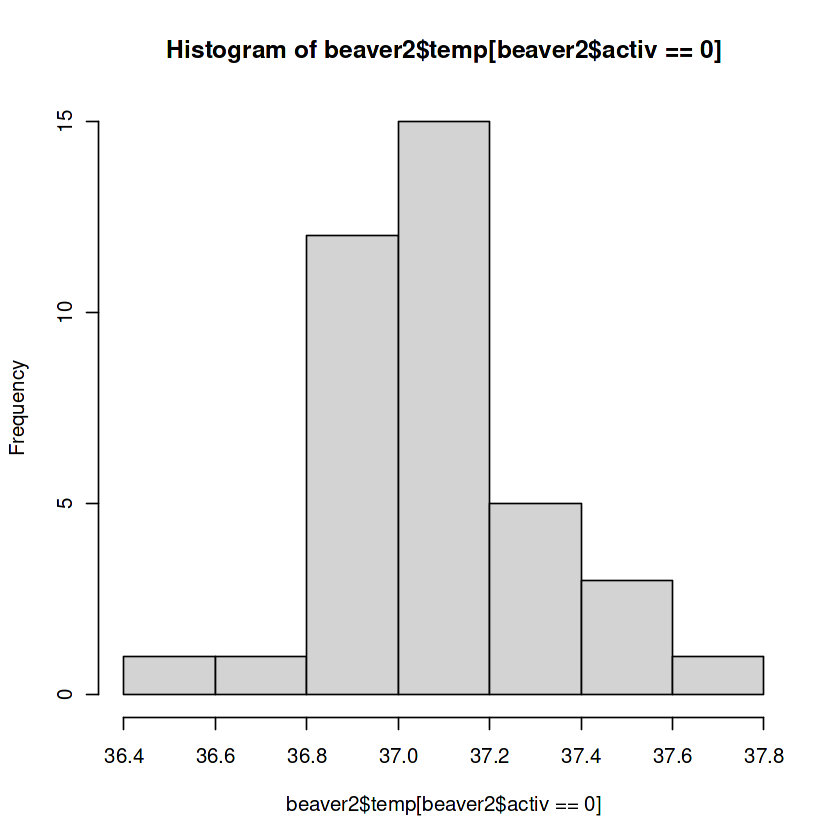


	Shapiro-Wilk normality test

data:  beaver2$temp[beaver2$activ == 0]
W = 0.95427, p-value = 0.1231



	Shapiro-Wilk normality test

data:  beaver2$temp[beaver2$activ == 1]
W = 0.98326, p-value = 0.5583


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1,0.9148506,0.3411843
,98,NA,NA


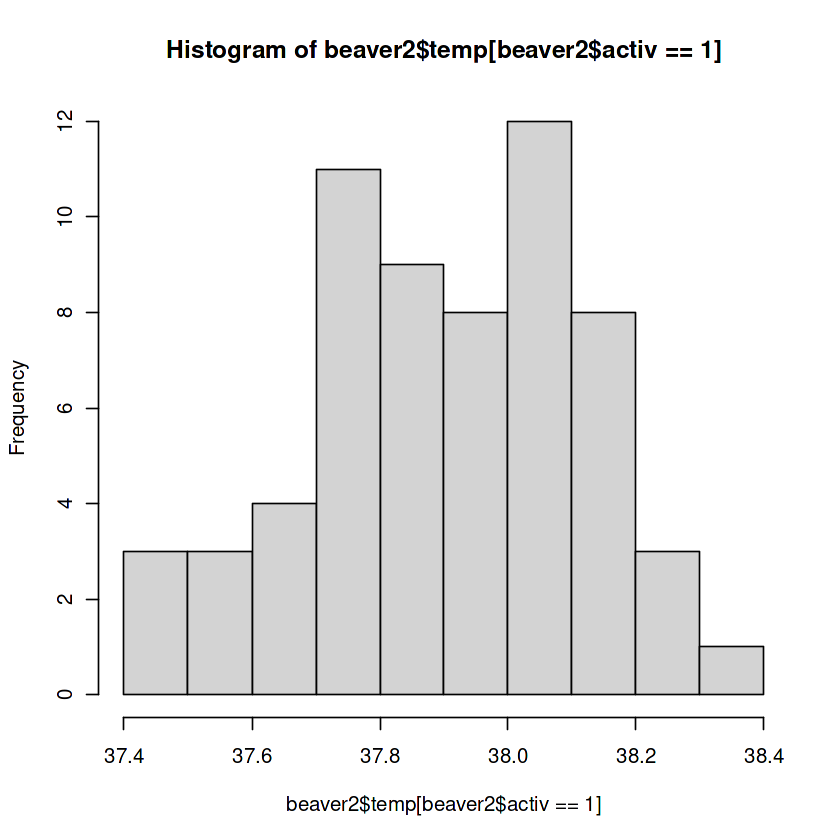

In [ ]:
hist(beaver2$temp[beaver2$activ == 0])
hist(beaver2$temp[beaver2$activ == 1])

shapiro.test(beaver2$temp[beaver2$activ == 0])
shapiro.test(beaver2$temp[beaver2$activ == 1])

leveneTest(temp ~ activ, beaver2)


Based on our Shapiro test and Levene test p-values and outputs, we cannot reject the null hypothesis that our data is normal and homoscedastic.

---

### Welch's t-test

If the two groups are normally distributed but do not have equal variance, then perform a Welch's t-test.

Let's modify our dataset to create unequal variances in temperature between our active and inactive beavers and assume for now that the data is normal.



In [ ]:
beaver2$temp_mod <- beaver2$temp
beaver2$temp_mod[beaver2$activ == 0] <- beaver2$temp[beaver2$activ == 0] ^ (8/9)

Let us double check that our variances are now different with `leveneTest()`:


In [ ]:
leveneTest(temp_mod ~ activ, data = beaver2)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1,15.96672,0.0001248691
,98,NA,NA


From the above result, we have enough evidence to reject the null hypothesis, indicating that the variance across the samples is not equal \($W = 15.97$, $p = 0.0001$\). Note that the test statistic uses the symbol $W$. Plotting this (with `plot()`) can help visualize the difference in spread:

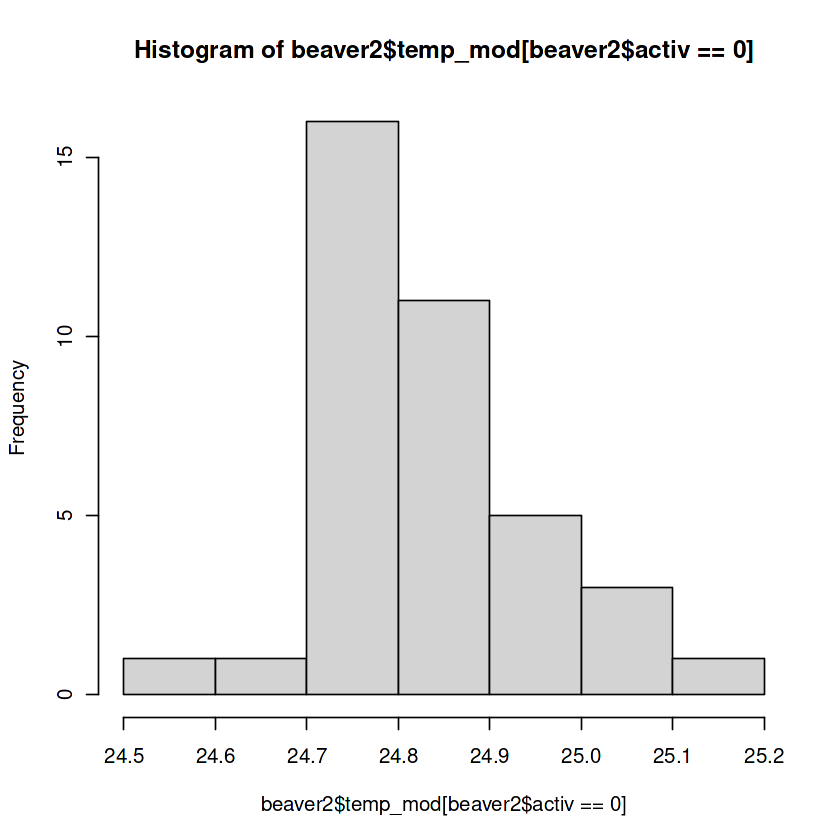

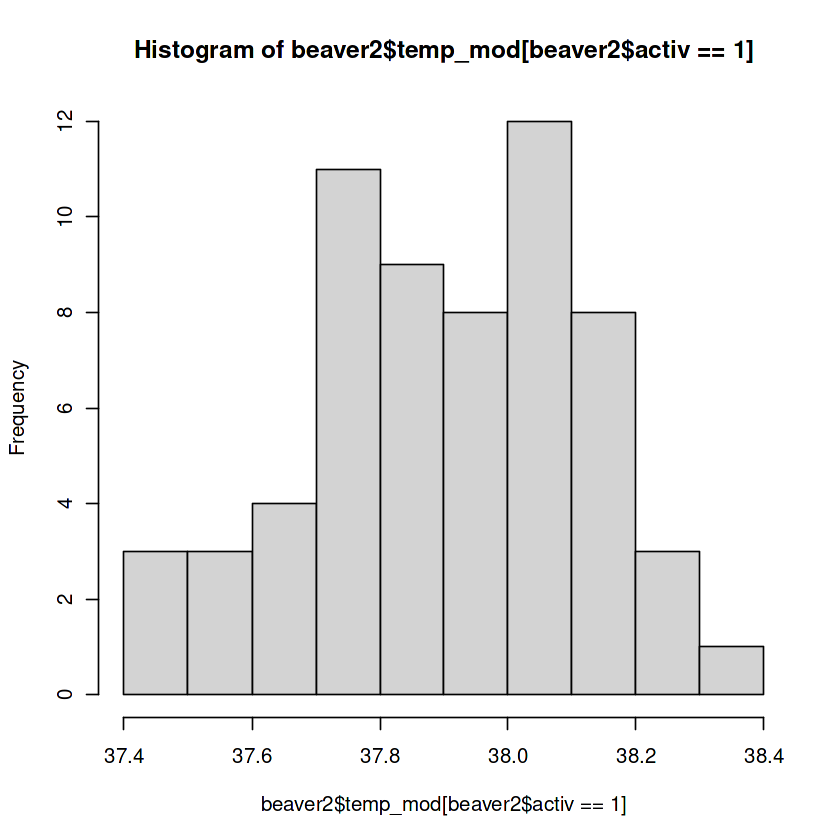

In [ ]:
hist(beaver2$temp_mod[beaver2$activ == 0])
hist(beaver2$temp_mod[beaver2$activ == 1])

Let's perform our t-test of unequal variance using the Welch's test with `t.test()`.

In [ ]:
t.test(temp_mod ~ activ, data = beaver2, var.equal = FALSE)



	Welch Two Sample t-test

data:  temp_mod by activ
t = -384.53, df = 97.625, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -13.14118 -13.00623
sample estimates:
mean in group 0 mean in group 1 
       24.82936        37.90306 


From this test, we can see that there is a significant difference in temperature between the two groups of beavers, while taking into consideration the unequal variances ($t = -1152.5$, $p < 0.05$).

---

### Mann-Whitney U-test

If your data is not normally distributed, it will be inappropriate to perform a regular t-test. Instead, you will have to use the non-parametric version of the t-test, called the Mann-Whitney U-test (or Wilcoxon rank sum test), which uses a ranked order instead of group means.

Let's perform this non-parametric test. Note that the function is called the `wilcox.test()` from base R:


In [ ]:
wilcox.test(temp ~ activ, data = beaver2)


	Wilcoxon rank sum test with continuity correction

data:  temp by activ
W = 15, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


From the output, we can see that there is a significant difference in temperatures between active and inactive beavers, without assuming normal distribution ($U = 15$, $p < 0.05$). Note that the test statistic for the Mann-Whitney U-test is commonly called $U$.


---
### Paired t-tests

A paired t-test is used to test whether two paired groups have different means. Usually, paired t-tests test groups before and after treatment, or between two sides of the body (e.g., left and right hand, left and right side of the brain). Importantly, these two groups **must not be independent from each other**, in addition to being normally distributed.

We can add the paired argument into our `t.test()` function to test paired samples. Let's use the dataset `anorexia` from the `MASS` package that compares weight of young female patients with anorexia before and after treatment.


In [ ]:
# Try out the various paired t-tests using the "Prewt" and "Postwt" columns from the "anorexia" dataset and check if it matches the results described later
head(anorexia)

t.test(anorexia$Prewt, anorexia$Postwt, paired=TRUE)


,Treat,Prewt,Postwt,Prewt_mod,Postwt_mod
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
1,Cont,80.7,80.2,276211151450,6432.04
2,Cont,89.4,80.1,510534520424,6416.01
3,Cont,91.8,86.4,598488882256,7464.96
4,Cont,74.0,86.3,164206490176,7447.69
5,Cont,78.1,76.1,226937467083,5791.21
6,Cont,88.3,78.1,473984589097,6099.61



	Paired t-test

data:  anorexia$Prewt and anorexia$Postwt
t = -2.9376, df = 71, p-value = 0.004458
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -4.6399424 -0.8878354
sample estimates:
mean difference 
      -2.763889 


The mean of the differences in output is group 1 minus group 2. In this example, `Prewt` minus `Postwt` is, on average, -2.76. Since this number is negative, that means `Postwt` (group 2) is larger. And, we can conclude that there is a statistically significant difference between weights before and after treatment ($t = -2.94$, $p = 0.004$).

Note that paired t-tests do not need to assume equal variance -- instead, it assumes that the variances are unknown.

---
### Paired Wilcoxon Signed Rank Test

You can perform non-parametric paired t-tests if the data are not normally distributed. This is called the Wilcoxon Signed Rank Test, and it compares whether two groups are identical without assuming
that they are normal.

Let's modify our two data columns, confirm that they are both no longer normal, and perform the paired samples Wilcoxon test.

In [ ]:
anorexia$Prewt_mod <- anorexia$Prewt^(6)
anorexia$Postwt_mod <- anorexia$Postwt^(2)

# Check if data is normally distributed
shapiro.test(anorexia$Prewt_mod)
shapiro.test(anorexia$Postwt_mod)


# Wilcoxon Signed Rank Test
wilcox.test(anorexia$Prewt_mod, anorexia$Postwt_mod, paired=TRUE)



	Shapiro-Wilk normality test

data:  anorexia$Prewt_mod
W = 0.95366, p-value = 0.009829



	Shapiro-Wilk normality test

data:  anorexia$Postwt_mod
W = 0.95624, p-value = 0.01362



	Wilcoxon signed rank test with continuity correction

data:  anorexia$Prewt_mod and anorexia$Postwt_mod
V = 2628, p-value = 1.694e-13
alternative hypothesis: true location shift is not equal to 0


From the above Shapiro-Wilk test for normality, we can see that both pre- and post-treatment weight of patients are not normally distributed (p-values are less than 0.05).

And, from the paired Wilcoxon test, there is a significant difference between pre- and post-treatment weight of anorexia patients while controlling for the non-normal distribution ($V = 2628$, $p = 0.01$).

Phew, that was a lot of tests just comparing two different groups! Let's move on to compare between more than two groups.

---
## Analysis of Variance (ANOVA)

An analysis of variance (ANOVA for short) tests the difference between three or more groups of data.

The null hypothesis of the ANOVA states that there is no difference in means, and the alternative hypothesis states that at least one mean is different from another mean. Thus, post-hoc tests are required after performing the statistical test in order to deduce which means are different.

ANOVAs have three assumptions: the data in each group is normally distributed, groups have equal variance (homoscedasticity), and that these observations are independent (not paired; i.e., samples in group 1 are not related to group 2).

Let's use the `ChickWeight` dataset to perform our one-way ANOVA (testing one factor). In this dataset, there are 4 different diets in the `Diet` column, numbered 1-4 -- let's test the effect of diet on the weight of chicks.

First, let's check for normality and equal variance.

In [ ]:
# Try out the next few tests using "weight" and "Diet" in the "ChickWeight" dataset
head(ChickWeight)
dim(ChickWeight)

unique(ChickWeight$Diet)  # Check how many different diets there are

,weight,Time,Chick,Diet
,<dbl>,<dbl>,<ord>,<fct>
1,42,0,1,1
2,51,2,1,1
3,59,4,1,1
4,64,6,1,1
5,76,8,1,1
6,93,10,1,1


[1] 578   4

[1] 1 2 3 4
Levels: 1 2 3 4

Let's test whether there is a difference in the weight of the chicks between diets. The function for an ANOVA is `aov()`; then, we wrap the `summary()` funtion around the ANOVA object:

In [ ]:
chick_aov <- aov(weight ~ Diet, data=ChickWeight)
summary(chick_aov)

             Df  Sum Sq Mean Sq F value   Pr(>F)    
Diet          3  155863   51954   10.81 6.43e-07 ***
Residuals   574 2758693    4806                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

From the results, we can see that there is a statistically significant difference in the weights of chicks between diets ($F = 10.81$, $p = 6.43 * 10^{-7}$). Which diets?

Let's perform a Tukey honest significant difference (HSD) test `TukeyHSD()` to compare between pairs. Note that you will not need to perform post-hoc tests if there is no significant difference found between groups in the ANOVA test. This post-hoc test will control for multiple pair-wise comparisons:

In [ ]:
TukeyHSD(chick_aov)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = weight ~ Diet, data = ChickWeight)

$Diet
         diff         lwr      upr     p adj
2-1 19.971212  -0.2998092 40.24223 0.0552271
3-1 40.304545  20.0335241 60.57557 0.0000025
4-1 32.617257  12.2353820 52.99913 0.0002501
3-2 20.333333  -2.7268370 43.39350 0.1058474
4-2 12.646045 -10.5116315 35.80372 0.4954239
4-3 -7.687288 -30.8449649 15.47039 0.8277810


From these pairwise comparisons, we can see that there is a significant difference between group 3 and 1 (where group 3 has a mean of 40 units more than group 1), and group 4 and 1 (where group 4 has a mean of 33 units more than group 1).

---
### Kruskal-Wallis rank sum test

If our ANOVA assumptions are not met, we will need to perform the non-parametric version of the ANOVA, called the Kruskal-Wallis test.

Let's take a look at some diagnostic plots with `plot()`:

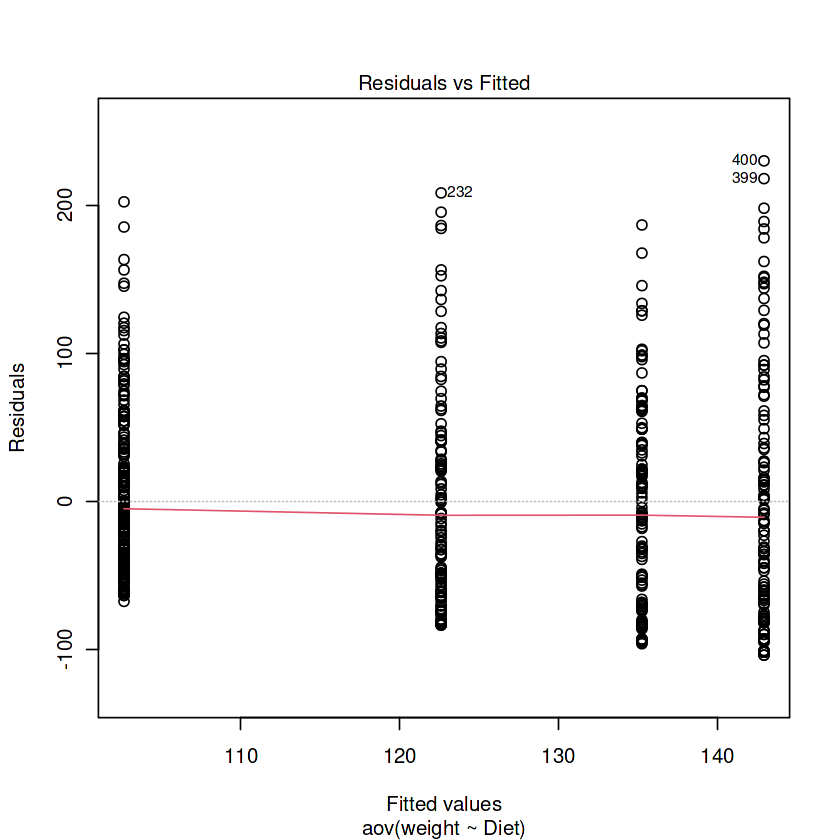

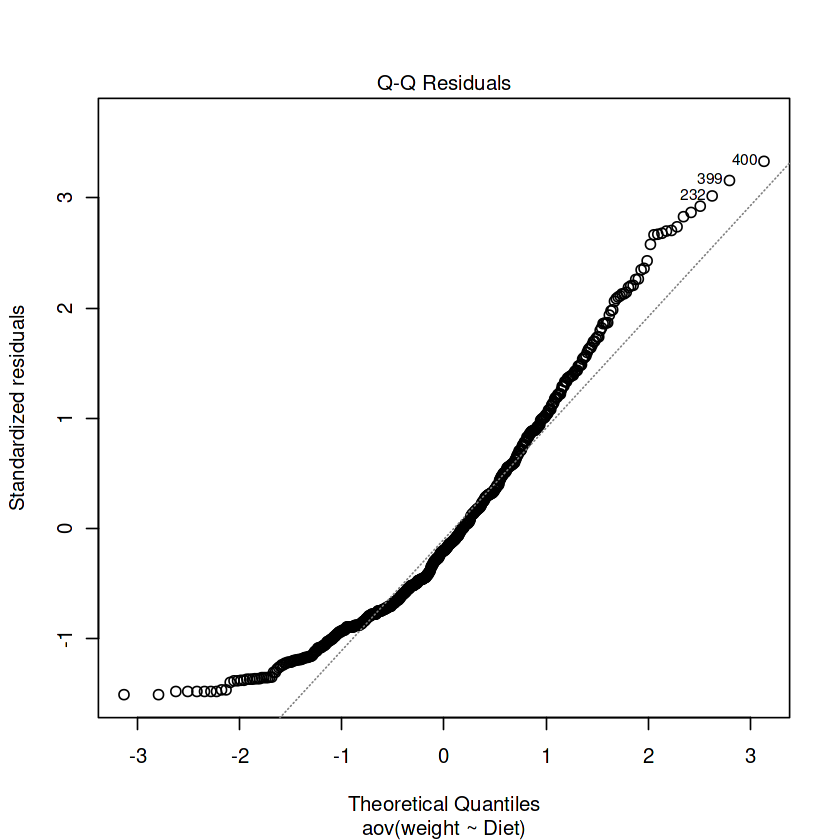

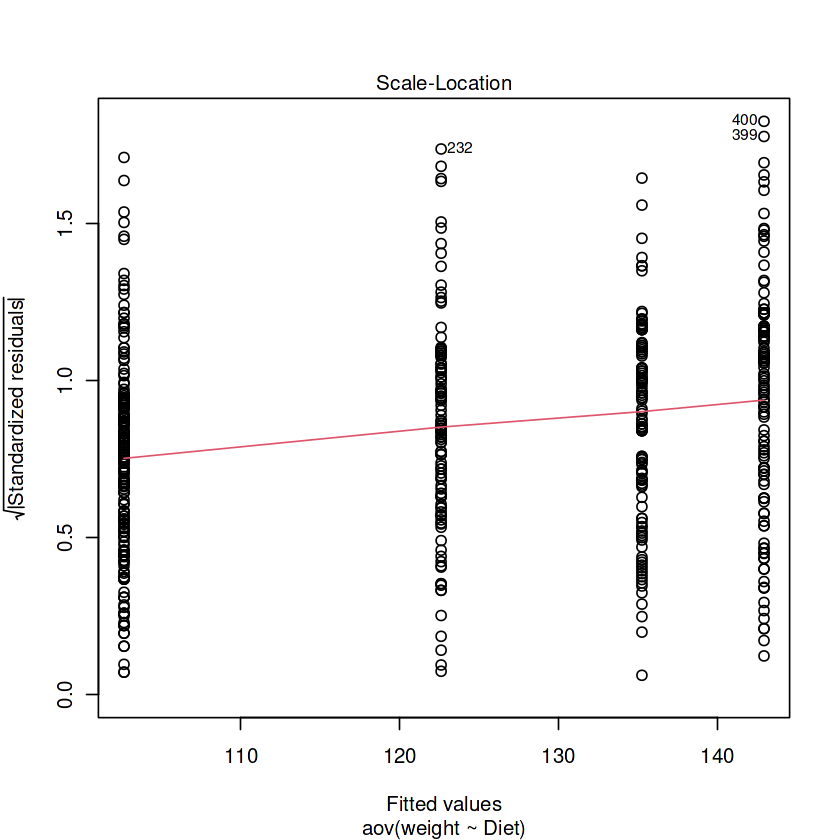

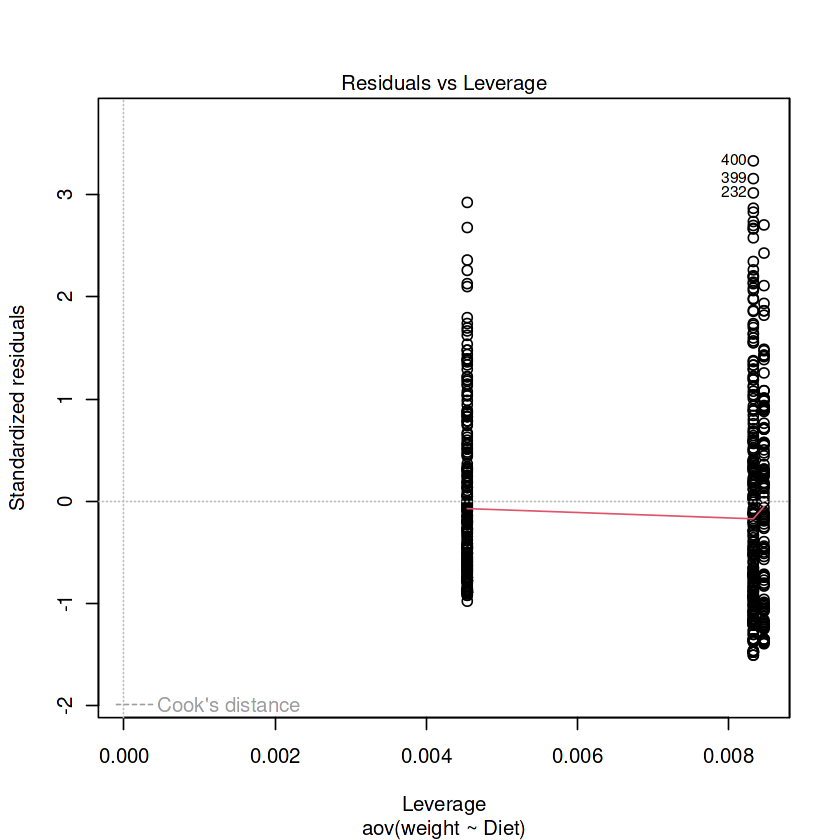

In [ ]:
plot(chick_aov)  # For the first plot, we are looking for a normal distribution of variables; for the second plot, we are looking for alignment with the dotted line

And also perform our tests of normality (on the residuals) and homoscedasticity:

In [ ]:
shapiro.test(chick_aov$residuals)
leveneTest(weight ~ Diet, data = ChickWeight)


	Shapiro-Wilk normality test

data:  chick_aov$residuals
W = 0.94065, p-value = 2.014e-14


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,3,9.600109,3.418342e-06
,574,NA,NA


We can see that our data fails both the assumption of normality and the assumption of equal variance (the p-value is less than $0.05$ for both tests). Thus, we need to perform the non-parametric version of the ANOVA, using the function `kruskal.test()` from base R:

In [ ]:
kruskal.test(weight ~ Diet, data = ChickWeight)


	Kruskal-Wallis rank sum test

data:  weight by Diet
Kruskal-Wallis chi-squared = 24.45, df = 3, p-value = 2.012e-05


From the output, we can see that there is a significant difference between at least one diet group ($H = 24.45$, $p = 2.01*10 ^{-5}$), but which one? We need to use the post-hoc test called the Dunn test `dunn_test()` after performing the Kruskal-Wallis test to test pairwise differences while controlling for the multiple comparisons. Let's use the Bonferonni correction for the p-values of the multiple comparisons (a more conservative correction that reduces the false discovery rate) with `p.adjust.method = "bonferroni"`.



In [ ]:
dunn_test(weight ~ Diet, data = ChickWeight, p.adjust.method = "bonferroni")

,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,weight,1,2,220,120,2.2509620,2.438794e-02,0.1463276617,ns
2,weight,1,3,220,120,4.0286054,5.610871e-05,0.0003366523,***
3,weight,1,4,220,118,4.0951645,4.218688e-05,0.0002531213,***
4,weight,2,3,120,120,1.5626357,1.181383e-01,0.7088297769,ns
5,weight,2,4,120,118,1.6339218,1.022753e-01,0.6136516305,ns
6,weight,3,4,120,118,0.0778656,9.379350e-01,1.0000000000,ns


From the output, we can see that there is a significant difference between groups 1 and 3 ($p = 0.0003$), and between groups 1 and 4 ($p = 0.0003$).

Note that there are a lot of other corrections options that you can use, but their usage depends on a case-by-case basis. Be careful of p-hacking!

---
### Repeated measures ANOVA

The repeated-measures ANOVA, or within-subjects ANOVA, is used for analyzing data where the same outcome variables are measured at different time points or conditions. The assumptions of a repeated measures ANOVA are: normal distribution of data at each timepoint, and constant variance across timepoints.


Let's use the `Orange` dataset as an example, which contains data about the growth (circumference at breast height, mm) of orange trees at different ages. Make sure to test for normality at each timepoint prior to running your ANOVA. The function is `anova_test()`, and to indicate that we are performing a repeated measures test, we have to specify the `wid` argument (for each individual), and the `within` argument (for the within-subjects test variable), in addition to the `dv` (dependent variable).


In [ ]:
# Try out the next few tests using  the "Orange" dataset
head(Orange)
tail(Orange)
dim(Orange)
summary(Orange)

orange_aov <- anova_test(data = Orange, dv = circumference, wid = Tree, within = age)
get_anova_table(orange_aov)

,Tree,age,circumference
,<ord>,<dbl>,<dbl>
1,1,118,30
2,1,484,58
3,1,664,87
4,1,1004,115
5,1,1231,120
6,1,1372,142


,Tree,age,circumference
,<ord>,<dbl>,<dbl>
30,5,484,49
31,5,664,81
32,5,1004,125
33,5,1231,142
34,5,1372,174
35,5,1582,177


[1] 35  3

 Tree       age         circumference  
 3:7   Min.   : 118.0   Min.   : 30.0  
 1:7   1st Qu.: 484.0   1st Qu.: 65.5  
 5:7   Median :1004.0   Median :115.0  
 2:7   Mean   : 922.1   Mean   :115.9  
 4:7   3rd Qu.:1372.0   3rd Qu.:161.5  
       Max.   :1582.0   Max.   :214.0  

,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,age,6,24,85.86,5.06e-15,*,0.855


From the results, we can see that the circumference of the trees was significantly different at the different time points during the data measurements (F = 83.9, $p = 5.06 * 10 ^ {-15}$). The generalized effect size (ges) is 0.86, which indicates the amount of variability due to the within-subjects factor (in our case, age). That means that, on average, there is a difference of 0.86 units in circumference between each of those timepoints.


We can perform multiple pairwise paired t-tests between the levels of the within-subjects factor (here time). P-values are adjusted using the Bonferroni multiple testing correction method. Remember that we have to always control for multiple testing.



In [ ]:
# pairwise comparisons
pairwise_t_test(
    circumference ~ age, paired = TRUE,
    p.adjust.method = "bonferroni",
data = Orange)

,.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,circumference,118,484,5,5,-8.676820,4,0.000971,0.020,*
2,circumference,118,664,5,5,-8.732029,4,0.000948,0.020,*
3,circumference,118,1004,5,5,-9.349422,4,0.000729,0.015,*
4,circumference,118,1231,5,5,-9.155995,4,0.000790,0.017,*
5,circumference,118,1372,5,5,-10.067691,4,0.000548,0.012,*
6,circumference,118,1582,5,5,-10.085268,4,0.000544,0.011,*
7,circumference,484,664,5,5,-7.554176,4,0.002000,0.035,*
8,circumference,484,1004,5,5,-8.327996,4,0.001000,0.024,*
9,circumference,484,1231,5,5,-8.112261,4,0.001000,0.026,*


From these results, we can see that, on average across all trees, all circumferences were different at all timepoints except for between trees aged 1004 and 1231, and between trees aged 1372 and 1582. So, post-hoc analyses with a Bonferroni adjustment revealed that all the pairwise differences between time points were statistically significantly different (p <= 0.05) except for those two timepoints.

---
## Chi-square test of independence

The Chi-square test is used to analyze a frequency table, or contingency table, formed by two categorical variables. It evaluates whether there is a significant association between the categories of the two variables.

Let's use the `survey` dataset from the `MASS` package to run the chi-square test. Let's test whether smoking is associated with exercise. The null hypothesis states that there is no relationship between smoking and exercise.

In [ ]:
# Use the survey dataset for the last few tests
head(survey)
dim(survey) # rows first, then columns

,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age,Smoke_grouped
,<fct>,<dbl>,<dbl>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<dbl>,<fct>,<dbl>,<chr>
1,Female,18.5,18.0,Right,R on L,92,Left,Some,Never,173.00,Metric,18.250,Never
2,Male,19.5,20.5,Left,R on L,104,Left,None,Regul,177.80,Imperial,17.583,Smokes
3,Male,18.0,13.3,Right,L on R,87,Neither,None,Occas,NA,NA,16.917,Smokes
4,Male,18.8,18.9,Right,R on L,NA,Neither,None,Never,160.00,Metric,20.333,Never
5,Male,20.0,20.0,Right,Neither,35,Right,Some,Never,165.00,Metric,23.667,Never
6,Female,18.0,17.7,Right,L on R,64,Right,Some,Never,172.72,Imperial,21.000,Never


[1] 237  13

First, let's create our contingency table, with smoking habit along the rows, and exercise habit along the columns using `table()`:

In [ ]:
survey_table <- table(survey$Smoke, survey$Exer)
survey_table

       
        Freq None Some
  Heavy    7    1    3
  Never   87   18   84
  Occas   12    3    4
  Regul    9    1    7

Now, we can apply the chi-square function `chisq.test()`:

In [ ]:
chisq.test(survey_table)

Warning message in chisq.test(survey_table):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  survey_table
X-squared = 5.4885, df = 6, p-value = 0.4828


From the output, we can likely conclude that the smoking habit is independent of the exercise level of the student ($\chi ^2 = 5.5$, $p = 0.48$) and hence there is a weak or no correlation between the two variables. However, note the warning message `“Chi-squared approximation may be incorrect”`. In cases where we have relatively small sample numbers, we may want to instead group certain categories together and re-do the test.

In [ ]:
# Grouping
survey$Smoke_grouped <- ifelse(survey$Smoke == "Never", "Never", "Smokes")
head(survey)

survey_grouped_table <- table(survey$Smoke_grouped, survey$Exer)
survey_grouped_table

# Chi-square test
chisq.test(survey_grouped_table)

,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age,Smoke_grouped
,<fct>,<dbl>,<dbl>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<dbl>,<fct>,<dbl>,<chr>
1,Female,18.5,18.0,Right,R on L,92,Left,Some,Never,173.00,Metric,18.250,Never
2,Male,19.5,20.5,Left,R on L,104,Left,None,Regul,177.80,Imperial,17.583,Smokes
3,Male,18.0,13.3,Right,L on R,87,Neither,None,Occas,NA,NA,16.917,Smokes
4,Male,18.8,18.9,Right,R on L,NA,Neither,None,Never,160.00,Metric,20.333,Never
5,Male,20.0,20.0,Right,Neither,35,Right,Some,Never,165.00,Metric,23.667,Never
6,Female,18.0,17.7,Right,L on R,64,Right,Some,Never,172.72,Imperial,21.000,Never


        
         Freq None Some
  Never    87   18   84
  Smokes   28    5   14

Warning message in chisq.test(survey_grouped_table):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  survey_grouped_table
X-squared = 3.412, df = 2, p-value = 0.1816


Despite grouping, we still receive the warning message `“Chi-squared approximation may be incorrect”`. In cases where we have relatively small sample numbers, where the Chi-square test may not be accurate and is therefore inappropriate to use, we can instead use the Fisher's exact test.

---
## Fisher's exact test

The Fisher's exact test is used to analyze a frequency table, or contingency table, formed by two categorical variables that is small in size. It evaluates whether there is a significant association between the categories of the two variables.

While the Chi-square test gives a p-value approximation that is accurate for larger sample sizes, Fisher's exact test gives exact p-values, as implied by the name and is much more appropriate for smaller datasets. What exactly defines a small dataset? Some statisticians draw the line at fewer than 1000 samples in total, or when more than 20% of cells have fewer than 5 samples expected.

Taking our previous contingency tables from the survey dataset, let us re-investigate our null hypothesis that there is no relationship between smoking and exercise with `fisher.test()`.

In [ ]:
fisher.test(survey_table)
fisher.test(survey_grouped_table)


	Fisher's Exact Test for Count Data

data:  survey_table
p-value = 0.4138
alternative hypothesis: two.sided



	Fisher's Exact Test for Count Data

data:  survey_grouped_table
p-value = 0.1745
alternative hypothesis: two.sided


From this output, we can finally conclude that the smoking habit is independent of the exercise level of the student using our newly calculated exact p-value ($p = 0.41$). Please note that the Fisher's exact test does not have a generally recognized test statistic due to how it is calculated. You can instead compare the different proportions of the groups across the dataset.

---

Woo! That was a lot of statsy fun! Remember that these are just some tools that you may need for your assignments. We will be continuing with more next week. In the meantime, please remember to work on Practice Problem 2 and Worksheet 1.